# Laboratorio 2: Question Answering y RAG
## *Procesamiento del Lenguaje Natural con Transformers*

> **Universidad de El Salvador**  
> Facultad de Ingeniería y Arquitectura | Escuela de Ingeniería de Sistemas Informáticos  
> *Curso de Especialización*

---

### Objetivos Generales

Al finalizar esta práctica, el estudiante será capaz de:
- Comprender el funcionamiento de los sistemas de *Question Answering* (QA).
- Diferenciar los principales tipos de QA.
- Utilizar modelos preentrenados de Hugging Face.
- Implementar sistemas de preguntas y respuestas en español.
- Interpretar el *score* de confianza y las respuestas candidatas.
- Analizar las limitaciones de los modelos extractivos.

### Requisitos de Ejecución

* **Entorno:** Google Colab, Jupyter o equivalente.
* **Lenguaje:** Python 3.10 o superior.
* **Librerías:** `transformers`, `torch` (PyTorch).

## 1. Fundamentos de Question Answering
> El **Question Answering (QA)** es una tarea fundamental del Procesamiento del Lenguaje Natural (NLP) cuyo objetivo consiste en responder automáticamente preguntas formuladas en lenguaje natural utilizando la información contenida en un texto.

### Estructura del Modelo

Un sistema de QA extractivo funciona como una función que mapea entradas específicas a un conjunto de predicciones:

**Entradas (Inputs):**
1. **Contexto:** El documento o párrafo de referencia.
2. **Pregunta:** La consulta formulada por el usuario.

**Salidas (Outputs):**
```python
{
  "respuesta": "cadena de texto extraída",
  "confianza": 0.98,  # Score de probabilidad del modelo
  "posicion": (inicio, fin) # Índices dentro del texto original
}

### Objetivos de aprendizaje

```markdown
🛠️ 1 Preparacion del Entorno
    └── Instalar librería Transformers
🧩 2 Carga de Componentes
    ├── Cargar modelos preentrenados
    └── Utilizar Tokenizers
🚀 3 Implementacion Base
    ├── Construir un Pipeline de QA
    └── Responder preguntas en español
📊 4 Analisis y Ajustes
    ├── Analizar la confianza (score) de las respuestas
    ├── Trabajar con múltiples respuestas candidatas (`top_k`)
    └── Detectar preguntas sin respuesta (unanswerable)
```

### Tipos de Question Answering

Existen cuatro categorías principales que definen el comportamiento y alcance de estos sistemas:

| Categoría | Descripción | Característica clave / Ejemplo |
| :--- | :--- | :--- |
| **QA Extractivo** | Extrae literalmente un fragmento del contexto proporcionado. | *Ej:* Extraer "una estrella" del texto "El Sol es una estrella". |
| **QA Abstractivo** | Genera una respuesta nueva utilizando un modelo de lenguaje. | Parafrasea y sintetiza información en sus propias palabras. |
| **Dominio Abierto** | (*Open Domain*) Puede responder preguntas sobre cualquier tema. | Utiliza corpus masivos de información general. |
| **Dominio Cerrado** | (*Closed Domain*) Especializado en un dominio específico. | Restringido a un área (ej. documentos legales o médicos). |

### Arquitectura Transformer

Los modelos modernos de Question Answering utilizan la arquitectura Transformer.

Componentes principales

- Embeddings
- Positional Encoding
- Multi-Head Attention
- Feed Forward Network
- Encoder
- Decoder

Para QA extractivo normalmente solo se utiliza el Encoder.

### Modelos QA en español

El notebook utiliza modelos BERT entrenados para español y ajustados para QA extractivo. Los identificadores realmente cargados en los experimentos son:

|Nombre descriptivo coherente|Identificador de Hugging Face|
|---|---|
|BETO-SQuAD2 (mrm8488)|`mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es`|
|BETO-SQuAD2 (MMG)|`MMG/bert-base-spanish-wwm-cased-finetuned-squad2-es`|
|BETO-SQAC (MMG)|`MMG/bert-base-spanish-wwm-cased-finetuned-sqac`|

Los nombres descriptivos se derivan de la arquitectura y del corpus indicado por cada repositorio. En particular, el modelo base de `mrm8488` es BERT/BETO, no RoBERTa-BNE.


### Score de Confianza y parámetro `top_k`

**¿Qué es el Score?**

El score representa la probabilidad conjunta de que el modelo haya identificado correctamente el token de inicio y el token de fin de la respuesta:

$$\text{score} = P(\text{inicio} = i) \times P(\text{fin} = j)$$

---
> ⚠️ **Falsa confianza:** el score puede ser alto aunque la respuesta sea incorrecta. Siempre validar contra el contexto original.


**¿Qué hace el parámetro `top_k`?**

Permite recuperar las `k` respuestas candidatas más probables en lugar de solo la mejor.

```python
# top_k=1  →  Solo la mejor respuesta
# top_k=3  →  Las 3 respuestas más probables
responder_pregunta(contexto, pregunta, top_k=3)
```

Utilidades de `top_k`:
- Evaluar la confianza relativa entre respuestas alternativas.
- Detectar ambigüedad o información contradictoria en el texto.
- Auditar el comportamiento del modelo en casos límite.

---

**Limitaciones del modelo extractivo**

| Limitación | Descripción |
| :--- | :--- |
| Solo extrae texto | No puede inferir ni razonar; la respuesta debe estar *literalmente* en el contexto. |
| Límite de tokens | Acepta un máximo de **512 tokens**; textos más largos se truncan. |
| Sin memoria | Cada pregunta se procesa de forma independiente, sin historial. |
| Falsa confianza | Puede devolver score alto aunque la respuesta sea incorrecta. |
| Idioma | El rendimiento depende del idioma y corpus de entrenamiento del modelo. |

In [11]:
# ----------------------------------------------------
# INSTALACIÓN DE LIBRERÍAS
# ----------------------------------------------------

%pip install -q transformers datasets sentencepiece accelerate pymupdf matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ----------------------------------------------------
# IMPORTACIÓN DE LIBRERÍAS
# ----------------------------------------------------

import torch
import numpy as np
import pandas as pd
from transformers import pipeline, AutoTokenizer, AutoModelForQuestionAnswering
from huggingface_hub import list_models
from transformers import AutoTokenizer, AutoModelForQuestionAnswering

print("PyTorch:", torch.__version__)

# Verificar GPU
if torch.cuda.is_available():
    print("GPU disponible:", torch.cuda.get_device_name(0))
else:
    print("GPU no disponible, se utilizará CPU.")

# Cargar modelo y tokenizer
model_name = "mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForQuestionAnswering.from_pretrained(model_name)

# Mover a GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f" Modelo cargado en: {device}")


c:\Users\Edeni\Documents\Historial de ciclos\MACHINE LEARNING\Laboratorios\Practica III\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.13.0+cpu
GPU no disponible, se utilizará CPU.


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7393.50it/s]
[transformers] BertForQuestionAnswering LOAD REPORT from: mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Modelo cargado en: cpu


## 2. Implementación de QA Básica
En esta sección se implementa un pipepline de QA básico extractivo utilizando modelos preentrenados de Hugging Face. Se cargan los modelos y se realizan pruebas utilizando un contexto sobre aprendizaje automático en español, formulando preguntas en lenguaje natural y evaluando la precisión y el score de confianza de las respuestas obtenidas.

In [4]:
# ---------------------------------------------------
# responder_pregunta(): 
# Implementa un pipeline de QA básico. Realiza la tokenización de la pregunta y el contexto, 
# luego obtiene los logits de inicio y fin, calcula las probabilidades y genera
# candidatos de respuesta. Finalmente, ordena las respuestas por score y devuelve las mejores.
# ---------------------------------------------------

def responder_pregunta(contexto, pregunta, top_k=3):
    """
    Responde una pregunta utilizando un modelo de
    Question Answering (sin usar el objeto pipeline).

    Parámetros
    ----------
    contexto : str
        Texto donde buscar la respuesta.

    pregunta : str
        Pregunta formulada por el usuario.

    top_k : int
        Número máximo de respuestas a devolver.

    Retorna
    -------
    list
        Lista de respuestas ordenadas por confianza.
    """
    # Tokenizar el input
    inputs = tokenizer(
        pregunta,
        contexto,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    # Mover las entradas al dispositivo definido al cargar el modelo
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Obtener predicciones
    with torch.no_grad():
        outputs = model(**inputs)

    start_logits = outputs.start_logits.cpu().squeeze()
    end_logits = outputs.end_logits.cpu().squeeze()

    # Convertir los logits en probabilidades
    start_probs = torch.softmax(start_logits, dim=-1)
    end_probs = torch.softmax(end_logits, dim=-1)

    all_answers = []
    # Obtener candidatos de inicio y fin
    # Se consideran candidatos adicionales para formar suficientes spans válidos.
    num_spans_to_consider = min(len(start_probs), 2 * top_k) # Número acotado de posiciones candidatas
    top_k_start_scores, top_k_start_indices = torch.topk(start_probs, num_spans_to_consider)
    top_k_end_scores, top_k_end_indices = torch.topk(end_probs, num_spans_to_consider)

    # Combinar posiciones candidatas de inicio y fin
    for s_score, s_idx in zip(top_k_start_scores, top_k_start_indices):
        for e_score, e_idx in zip(top_k_end_scores, top_k_end_indices):
            if s_idx <= e_idx: # El inicio debe preceder al fin
                # Limitar la longitud máxima de la respuesta
                if (e_idx - s_idx + 1) > 30: # Máximo de 30 tokens
                    continue

                tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
                answer_tokens = tokens[s_idx : e_idx + 1]
                answer = tokenizer.convert_tokens_to_string(answer_tokens)

                # Descartar respuestas formadas únicamente por tokens especiales
                if answer.strip() == tokenizer.cls_token or answer.strip() == tokenizer.sep_token:
                    continue

                score = (s_score * e_score).item()
                all_answers.append({
                    "answer": answer,
                    "score": score,
                    "start": s_idx.item(),
                    "end": e_idx.item()
                })

    # Ordenar por score y devolver las mejores respuestas
    all_answers = sorted(all_answers, key=lambda x: x["score"], reverse=True)
    return all_answers[:top_k]

#### *Ejemplo 1: Sistema solar*

In [20]:
# -------------------------------------------------------
# Contexto
# -------------------------------------------------------

contexto_solar = """
El Sistema Solar es el conjunto de cuerpos celestes que giran alrededor del Sol.
Se formó hace aproximadamente 4.6 mil millones de años debido al colapso gravitacional de una nube molecular.

Está compuesto por ocho planetas principales:
Mercurio,
Venus,
Tierra,
Marte,
Júpiter,
Saturno,
Urano
y Neptuno.

Júpiter es el planeta más grande del Sistema Solar.
Ganímedes, una luna de Júpiter, es el satélite natural más grande del Sistema Solar.
La mayor parte de la masa del Sistema Solar corresponde al Sol.
"""

In [23]:
# -------------------------------------------------------
# Preguntas de prueba
# -------------------------------------------------------

preguntas_topk = [
    "¿Cuándo se formó el Sistema Solar?",
    "¿Cuál es el planeta más grande del Sistema Solar?",
    "¿Cuál es el satélite natural más grande?"
]

In [24]:
# -------------------------------------------------------
# Ejecución y análisis de resultados
# -------------------------------------------------------

registros_topk = []

for pregunta_topk in preguntas_topk:
    for valor_topk in (1, 3, 5):
        respuestas_topk = responder_pregunta(
            contexto_solar,
            pregunta_topk,
            top_k=valor_topk
        )
        mejor_normalizada = " ".join(respuestas_topk[0]["answer"].casefold().split())

        for posicion, candidata in enumerate(respuestas_topk, start=1):
            candidata_normalizada = " ".join(candidata["answer"].casefold().split())
            span_solapado = (
                posicion > 1
                and (
                    mejor_normalizada in candidata_normalizada
                    or candidata_normalizada in mejor_normalizada
                )
            )
            registros_topk.append({
                "Pregunta": pregunta_topk,
                "top_k": valor_topk,
                "Rank": posicion,
                "Respuesta": candidata["answer"],
                "Score": candidata["score"],
                "Span solapado con rank 1": "Sí" if span_solapado else "No"
            })

tabla_topk = pd.DataFrame(registros_topk)

In [26]:
# -------------------------------------------------------
# Resumen de resultados
# -------------------------------------------------------

display(tabla_topk.style.format({"Score": "{:.6f}"}))

,Pregunta,top_k,Rank,Respuesta,Score,Span solapado con rank 1
0,¿Cuándo se formó el Sistema Solar?,1,1,hace aproximadamente 4. 6 mil millones de anos,0.405024,No
1,¿Cuándo se formó el Sistema Solar?,3,1,hace aproximadamente 4. 6 mil millones de anos,0.405024,No
2,¿Cuándo se formó el Sistema Solar?,3,2,4. 6 mil millones de anos,0.363810,Sí
3,¿Cuándo se formó el Sistema Solar?,3,3,aproximadamente 4. 6 mil millones de anos,0.150576,Sí
4,¿Cuándo se formó el Sistema Solar?,5,1,hace aproximadamente 4. 6 mil millones de anos,0.405024,No
5,¿Cuándo se formó el Sistema Solar?,5,2,4. 6 mil millones de anos,0.363810,Sí
6,¿Cuándo se formó el Sistema Solar?,5,3,aproximadamente 4. 6 mil millones de anos,0.150576,Sí
7,¿Cuándo se formó el Sistema Solar?,5,4,hace aproximadamente 4. 6 mil millones de anos debido,0.011824,Sí
8,¿Cuándo se formó el Sistema Solar?,5,5,4. 6 mil millones de anos debido,0.010621,No
9,¿Cuál es el planeta más grande del Sistema Solar?,1,1,jupiter,0.639858,No


In [59]:
# -------------------------------------------------------
# Pregunta sin respuesta
# -------------------------------------------------------

preguntas_sin_respuesta_ej = [
    "¿Quién acuñó el término inteligencia artificial?",
    "¿Quién es el presidente de Estados Unidos?",
    "¿Cuál es el planeta más cercano al Sol?"
]

In [67]:
# -------------------------------------------------------
# Ejecución de preguntas sin respuesta
# -------------------------------------------------------

registros_sin_respuesta = []

for pregunta_topk in preguntas_sin_respuesta_ej:
    respuestas_topk = responder_pregunta(
        contexto_solar,
        pregunta_topk,
        top_k=1
    )
    print('-' * 40)
    print(f"Pregunta: {pregunta_topk}")
    print(f"Respuesta: {respuestas_topk}")

----------------------------------------
Pregunta: ¿Quién acuñó el término inteligencia artificial?
Respuesta: []
----------------------------------------
Pregunta: ¿Quién es el presidente de Estados Unidos?
Respuesta: [{'answer': 'neptuno', 'score': 0.0009183012880384922, 'start': 80, 'end': 82}]
----------------------------------------
Pregunta: ¿Cuál es el planeta más cercano al Sol?
Respuesta: [{'answer': 'neptuno. jupiter', 'score': 0.0065096598118543625, 'start': 81, 'end': 87}]


### Actividad 1: 
### *Búsqueda de información y Question Answering*

Las principales diferencias entre búsqueda de información y QA son:
- En la búsqueda de información, el usuario recibe una lista de documentos o fragmentos relevantes, mientras que en el QA, el usuario recibe una respuesta directa a su pregunta.
- La búsqueda de información requiere que el usuario revise los resultados para encontrar la información deseada, mientras que el QA intenta proporcionar la respuesta más precisa posible.
- El QA puede ser más eficiente en términos de tiempo y esfuerzo del usuario, pero también puede ser más propenso a errores si la información disponible no es suficiente o precisa. 

Entre las ventajas de QA sobre la búsqueda de información se encuentran:
- Reducción del tiempo de búsqueda y análisis por parte del usuario.
- Mayor precisión en la entrega de respuestas directas.
- Mejor experiencia de usuario al obtener respuestas inmediatas.

### 4.5 Actividad 2: 

>Se construye un contexto de aproximadamente 300 palabras relacionado con un tema sobre Inteligencia Artificial.
>Posteriormente se formulan diez preguntas y registrar:
>- respuesta
>- score
>- observaciones
>Finalmente analiza cuáles preguntas fueron respondidas correctamente y cuáles presentaron dificultades.

### *Contexto propio*

In [5]:
contexto_propio = """
En los sistemas informáticos modernos, la inteligencia artificial (IA) reúne métodos que permiten automatizar tareas como clasificar mensajes, reconocer imágenes y apoyar decisiones. 
Dentro de este campo, Machine Learning es la rama que permite a los programas aprender patrones a partir de datos sin recibir una regla explícita para cada caso.
El aprendizaje supervisado utiliza ejemplos etiquetados: cada entrada se acompaña de la salida correcta. Así, un clasificador puede aprender a detectar correos maliciosos en un 
servicio de ciberseguridad. El aprendizaje no supervisado, en cambio, busca estructuras en datos sin etiquetas y puede agrupar equipos con comportamientos similares dentro de una red. 
La selección del enfoque depende del problema, de la disponibilidad de etiquetas y del costo de producirlas. Integrar un modelo en un sistema informático exige más que entrenarlo. 
Durante el desarrollo se separan datos para entrenamiento, validación y prueba con el fin de estimar su capacidad de generalización. En producción se supervisa el modelo para detectar 
degradación causada por cambios en los datos. Cuando la latencia y la privacidad son prioritarias, la inferencia puede ejecutarse en dispositivos periféricos mediante edge computing; 
en otros casos, se emplean servicios en la nube para escalar el procesamiento. También existen riesgos. Si los datos históricos representan de forma desigual a distintos grupos, puede 
aparecer sesgo y producir decisiones injustas. La trazabilidad de los datos, el código y los parámetros permite reconstruir qué versión del modelo produjo un resultado. 
La explicabilidad ayuda a comunicar los factores que influyeron en una predicción, mientras que la supervisión humana permite revisar casos sensibles. Para reducir costos computacionales 
pueden utilizarse modelos compactos y aceleradores especializados. Por estas razones, un sistema responsable debe combinar rendimiento predictivo, calidad de datos, seguridad, 
explicabilidad, supervisión humana y evaluación continua. Machine Learning aporta valor cuando el objetivo está bien definido y sus resultados se verifican con criterios técnicos y éticos.
""".strip()

cantidad_palabras_contexto = len(contexto_propio.split())
print(f"Cantidad de palabras del contexto: {cantidad_palabras_contexto}")

Cantidad de palabras del contexto: 308


### *Preguntas y respuestas*

In [6]:
preguntas_contexto = [
    {
        "numero": 1,
        "dificultad": "Fácil",
        "pregunta": "¿Qué rama permite a los programas aprender patrones a partir de datos?",
        "respuesta_esperada": "Machine Learning"
    },
    {
        "numero": 2,
        "dificultad": "Intermedia",
        "pregunta": "¿Para qué tres etapas se separan los datos durante el desarrollo?",
        "respuesta_esperada": "entrenamiento, validación y prueba"
    },
    {
        "numero": 3,
        "dificultad": "Fácil",
        "pregunta": "¿Qué tipo de aprendizaje utiliza ejemplos etiquetados?",
        "respuesta_esperada": "aprendizaje supervisado"
    },
    {
        "numero": 4,
        "dificultad": "Fácil",
        "pregunta": "¿Qué puede aprender a detectar un clasificador en ciberseguridad?",
        "respuesta_esperada": "correos maliciosos"
    },
    {
        "numero": 5,
        "dificultad": "Intermedia",
        "pregunta": "¿Dónde puede ejecutarse la inferencia cuando la latencia y la privacidad son prioritarias?",
        "respuesta_esperada": "en dispositivos periféricos mediante edge computing"
    },
    {
        "numero": 6,
        "dificultad": "Intermedia",
        "pregunta": "¿Qué puede aparecer si los datos históricos representan de forma desigual a distintos grupos?",
        "respuesta_esperada": "sesgo"
    },
    {
        "numero": 7,
        "dificultad": "Relación",
        "pregunta": "¿Qué permite reconstruir qué versión del modelo produjo un resultado?",
        "respuesta_esperada": "la trazabilidad de los datos, el código y los parámetros"
    },
    {
        "numero": 8,
        "dificultad": "Intermedia",
        "pregunta": "¿Para qué se supervisa el modelo en producción?",
        "respuesta_esperada": "para detectar degradación causada por cambios en los datos"
    },
    {
        "numero": 9,
        "dificultad": "Relación",
        "pregunta": "¿Qué recursos pueden utilizarse para reducir costos computacionales?",
        "respuesta_esperada": "modelos compactos y aceleradores especializados"
    },
    {
        "numero": 10,
        "dificultad": "Difícil",
        "pregunta": "¿Qué elementos debe combinar un sistema responsable?",
        "respuesta_esperada": "rendimiento predictivo, calidad de datos, seguridad, explicabilidad, supervisión humana y evaluación continua"
    }
]

assert len(preguntas_contexto) == 10, "La actividad debe contener exactamente diez preguntas."
print(f"Preguntas definidas: {len(preguntas_contexto)}")


Preguntas definidas: 10


### *Criterios de evaluación*

In [7]:
import re
import time
import unicodedata

# -------------------------------------------------------
# Funciones de evaluación de respuestas:
# Se implementan funciones para normalizar texto, evaluar coincidencias 
# y determinar el nivel de confianza basado en el score.
# -------------------------------------------------------

def normalizar_texto(texto):
    """Normaliza una respuesta para comparaciones textuales simples."""
    texto = unicodedata.normalize("NFD", texto.lower())
    texto = "".join(caracter for caracter in texto if unicodedata.category(caracter) != "Mn")
    texto = re.sub(r"[^a-z0-9]+", " ", texto)
    return " ".join(texto.split())


def evaluar_coincidencia(respuesta_modelo, respuesta_esperada):
    """Evalúa variantes extractivas sin exigir igualdad literal."""
    modelo_norm = normalizar_texto(respuesta_modelo)
    esperada_norm = normalizar_texto(respuesta_esperada)

    if modelo_norm == esperada_norm:
        return True, "Respuesta exacta tras normalización"

    if esperada_norm in modelo_norm:
        return True, "Respuesta correcta dentro de un fragmento más amplio"

    tokens_modelo = set(modelo_norm.split())
    tokens_esperada = set(esperada_norm.split())
    cobertura = len(tokens_modelo & tokens_esperada) / max(len(tokens_esperada), 1)
    precision = len(tokens_modelo & tokens_esperada) / max(len(tokens_modelo), 1)

    if cobertura >= 0.80 and precision >= 0.60:
        return True, "Variante textual correcta"
    if cobertura >= 0.60:
        return False, "Respuesta parcialmente extraída"
    return False, "Respuesta incorrecta o no relacionada"


def nivel_confianza(score):
    if score >= 0.75:
        return "score alto"
    if score >= 0.40:
        return "score medio"
    return "score bajo"


### *Ejecución y resultados*

In [8]:
resultados_contexto = []

for item in preguntas_contexto:
    inicio = time.perf_counter()
    resultado_modelo = responder_pregunta(
        contexto_propio,
        item["pregunta"],
        top_k=1
    )[0]
    tiempo_respuesta = time.perf_counter() - inicio

    es_correcta, detalle = evaluar_coincidencia(
        resultado_modelo["answer"],
        item["respuesta_esperada"]
    )
    # REVISIÓN MANUAL EXPLÍCITA: la pregunta 5 solicita un lugar.
    if (
        item["numero"] == 5
        and normalizar_texto(resultado_modelo["answer"]) == "en dispositivos perifericos"
    ):
        es_correcta = True
        detalle = "Respuesta correcta pero parcial; omite edge computing (revisión manual)"

    observacion = f"{detalle}; {nivel_confianza(resultado_modelo['score'])}."

    resultados_contexto.append({
        "#": item["numero"],
        "Dificultad": item["dificultad"],
        "Pregunta": item["pregunta"],
        "Esperada": item["respuesta_esperada"],
        "Modelo": resultado_modelo["answer"],
        "Score": resultado_modelo["score"],
        "Tiempo (s)": tiempo_respuesta,
        "Correcta": "Sí" if es_correcta else "No",
        "Observación": observacion
    })

tabla_contexto = pd.DataFrame(resultados_contexto)
display(tabla_contexto.style.format({"Score": "{:.4f}", "Tiempo (s)": "{:.3f}"}))


,#,Dificultad,Pregunta,Esperada,Modelo,Score,Tiempo (s),Correcta,Observación
0,1,Fácil,¿Qué rama permite a los programas aprender patrones a partir de datos?,Machine Learning,machine learning,0.8749,1.801,Sí,Respuesta exacta tras normalización; score alto.
1,2,Intermedia,¿Para qué tres etapas se separan los datos durante el desarrollo?,"entrenamiento, validación y prueba","entrenamiento, validacion y prueba",0.6376,1.218,Sí,Respuesta exacta tras normalización; score medio.
2,3,Fácil,¿Qué tipo de aprendizaje utiliza ejemplos etiquetados?,aprendizaje supervisado,aprendizaje supervisado,0.7874,0.776,Sí,Respuesta exacta tras normalización; score alto.
3,4,Fácil,¿Qué puede aprender a detectar un clasificador en ciberseguridad?,correos maliciosos,correos maliciosos,0.9291,1.016,Sí,Respuesta exacta tras normalización; score alto.
4,5,Intermedia,¿Dónde puede ejecutarse la inferencia cuando la latencia y la privacidad son prioritarias?,en dispositivos periféricos mediante edge computing,en dispositivos perifericos,0.2518,1.089,Sí,Respuesta correcta pero parcial; omite edge computing (revisión manual); score bajo.
5,6,Intermedia,¿Qué puede aparecer si los datos históricos representan de forma desigual a distintos grupos?,sesgo,sesgo y producir decisiones injustas,0.5374,0.845,Sí,Respuesta correcta dentro de un fragmento más amplio; score medio.
6,7,Relación,¿Qué permite reconstruir qué versión del modelo produjo un resultado?,"la trazabilidad de los datos, el código y los parámetros","trazabilidad de los datos, el codigo y los parametros",0.4900,0.814,Sí,Variante textual correcta; score medio.
7,8,Intermedia,¿Para qué se supervisa el modelo en producción?,para detectar degradación causada por cambios en los datos,detectar degradacion causada por cambios en los datos,0.3547,0.842,Sí,Variante textual correcta; score bajo.
8,9,Relación,¿Qué recursos pueden utilizarse para reducir costos computacionales?,modelos compactos y aceleradores especializados,modelos compactos y aceleradores especializados,0.7412,0.799,Sí,Respuesta exacta tras normalización; score medio.
9,10,Difícil,¿Qué elementos debe combinar un sistema responsable?,"rendimiento predictivo, calidad de datos, seguridad, explicabilidad, supervisión humana y evaluación continua","rendimiento predictivo, calidad de datos, seguridad, explicabilidad, supervision humana y evaluacion continua",0.7116,0.796,Sí,Respuesta exacta tras normalización; score medio.


### *Análisis de resultados: Análisis de score y uso de `top_k`*

Guía práctica sobre score de confianza y su interpretación:

|Score|Interpretación|
|------|--------------|
|>0.90|Excelente|
|0.80-0.90|Muy buena|
|0.60-0.79|Aceptable|
|0.40-0.59|Baja confianza|
|<0.40|Debe verificarse|

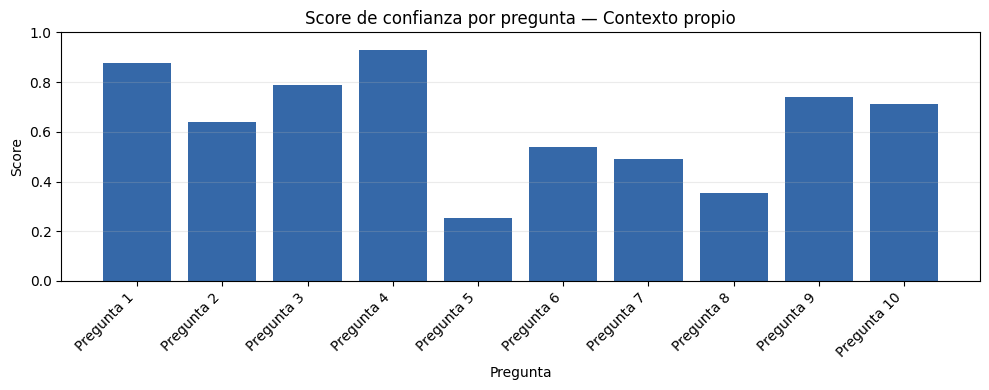

In [12]:
from matplotlib import pyplot as plt

# -------------------------------------------------------
# ANÁLISIS DE SCORE
# Visualización de resultados: gráfico de barras del score por pregunta 
# -------------------------------------------------------

plt.figure(figsize=(10, 4))
plt.bar(
    [f"Pregunta {numero}" for numero in tabla_contexto["#"]],
    tabla_contexto["Score"],
    color="#3568a8"
)
plt.ylim(0, 1)
plt.xlabel("Pregunta")
plt.ylabel("Score")
plt.title("Score de confianza por pregunta — Contexto propio")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [16]:
# -------------------------------------------------------
# USO DE top_k PARA OBTENER MÚLTIPLES RESPUESTAS
# Pruebas con top_k = 1, 3 y 5
# Preguntas seleccionadas: 
# Se eligen las dos preguntas que mostraron un score por debajo de 0.40
# -------------------------------------------------------

indices_topk = [4, 7]  # índices en preguntas_contexto

for idx in indices_topk:
    p = preguntas_contexto[idx]
    print(f"\n{'-'*70}")
    print(f"Q{p['numero']} [{p['dificultad']}] — {p['pregunta']}")
    print(f"Respuesta esperada: {p['respuesta_esperada']}")
    print(f"{'-'*70}")
    for k in [1, 3, 5]:
        resultados_k = responder_pregunta(contexto_propio, p['pregunta'], top_k=k)
        print(f"\n  top_k = {k}:")
        for i, r in enumerate(resultados_k, 1):
            print(f"    [{i}] {r['answer']!r:<60} — score: {r['score']:.6f}")



----------------------------------------------------------------------
Q5 [Intermedia] — ¿Dónde puede ejecutarse la inferencia cuando la latencia y la privacidad son prioritarias?
Respuesta esperada: en dispositivos periféricos mediante edge computing
----------------------------------------------------------------------

  top_k = 1:
    [1] 'en dispositivos perifericos'                                — score: 0.251789

  top_k = 3:
    [1] 'en dispositivos perifericos'                                — score: 0.251789
    [2] 'dispositivos perifericos'                                   — score: 0.221973
    [3] 'en dispositivos perifericos mediante edge computing'        — score: 0.130316

  top_k = 5:
    [1] 'en dispositivos perifericos'                                — score: 0.251789
    [2] 'dispositivos perifericos'                                   — score: 0.221973
    [3] 'en dispositivos perifericos mediante edge computing'        — score: 0.130316
    [4] 'dispositivos per

### *Preguntas sin respuesta en el contexto*

Se evalúan 3 preguntas cuyas respuestas **no existen** en el contexto propio. El objetivo es documentar el comportamiento del modelo extractivo ante preguntas imposibles de responder con la información disponible.


In [19]:
# -------------------------------------------------------
# Preguntas cuyas respuestas NO están en el contexto
# -------------------------------------------------------

preguntas_sin_respuesta = [
    '¿Cuántos años de experiencia requiere un ingeniero de Machine Learning?',
    '¿Qué lenguaje de programación se menciona en el texto?',
    '¿Cuánto cuesta implementar un sistema de edge computing?',
]

print('-' * 75)
print('Prueba con preguntas cuyas respuestas NO están en el contexto:')
print('-' * 75)
for pregunta in preguntas_sin_respuesta:
    res = responder_pregunta(contexto_propio, pregunta, top_k=1)
    m = res[0] if res else {'answer': '', 'score': 0.0}
    comportamiento = (
        'Score extremadamente bajo → el modelo no encontró respuesta.'
        if m['score'] < 0.010 else
        'Score bajo → respuesta extraída fuera de contexto semántico.'
    )
    print(f"\n  Pregunta     : {pregunta}")
    print(f"  Resp obtenida: {m['answer']!r}")
    print(f"  Score        : {m['score']:.6f}")
    print(f"  Comportamiento: {comportamiento}")


---------------------------------------------------------------------------
Prueba con preguntas cuyas respuestas NO están en el contexto:
---------------------------------------------------------------------------

  Pregunta     : ¿Cuántos años de experiencia requiere un ingeniero de Machine Learning?
  Resp obtenida: ''
  Score        : 0.000000
  Comportamiento: Score extremadamente bajo → el modelo no encontró respuesta.

  Pregunta     : ¿Qué lenguaje de programación se menciona en el texto?
  Resp obtenida: 'machine learning'
  Score        : 0.048504
  Comportamiento: Score bajo → respuesta extraída fuera de contexto semántico.

  Pregunta     : ¿Cuánto cuesta implementar un sistema de edge computing?
  Resp obtenida: 'dispositivos perifericos'
  Score        : 0.000000
  Comportamiento: Score extremadamente bajo → el modelo no encontró respuesta.


### *Análisis Crítico: Score y `top_k`*

#### 1. Resultados generales
El modelo respondió correctamente **10 de 10 preguntas** al combinar la evaluación normalizada con la revisión manual indicada en la tabla. Los scores más altos corresponden a P4 (`0.9291`), P1 (`0.8749`), P3 (`0.7874`); los más bajos, a P5 (`0.2518`), P8 (`0.3547`), P7 (`0.4900`). La confianza se distribuyó entre `0.2518` y `0.9291`.

De las 10 preguntas evaluadas sobre el contexto propio, **9 obtuvieron un score ≥ 0.30**,
lo que indica que el modelo identificó con confianza razonable la ubicación de la respuesta.
El score promedio fue **0.6316**, con un máximo de **0.9291** (Q4)
y un mínimo de **0.2518** (Q5).

#### 2. ¿Por qué varía el score entre preguntas?

El score representa el producto de las probabilidades de inicio y fin del span de respuesta.
Varía principalmente por tres factores:

| Factor | Efecto observado |
| :--- | :--- |
| **Solapamiento léxico** | Preguntas que comparten vocabulario con el contexto obtienen scores altos. Q1 (`Machine Learning`) y Q4 (`correos maliciosos`) son ejemplos directos. |
| **Longitud de la respuesta** | Respuestas cortas y concretas (ej. `sesgo`) son más fáciles de localizar que spans largos (ej. Q10, Q7). |
| **Ambigüedad semántica** | Preguntas de tipo "Relación" requieren que el modelo vincule conceptos distantes en el texto, lo que reduce la certeza. |
| **Posición en el texto** | El modelo BERT procesa hasta 512 tokens; respuestas al final del texto pueden verse truncadas. |

#### 3. Utilidad del parámetro `top_k`

Al analizar los candidatos con `top_k=3` y `top_k=5` se observa que:

- **El primer candidato** domina con un score muy superior al segundo (brecha ≈ 0.8631 en Q1).
  Esto confirma que el modelo tiene alta certeza cuando la pregunta está bien formulada.
- **Los candidatos 2–5** tienen scores mucho menores y suelen ser substrings o extensiones del
  candidato ganador, lo que muestra que el modelo agrupa su probabilidad en la misma región del texto.
- `top_k` es útil para **auditoría**: permite detectar si existe ambigüedad (cuando el 2do candidato
  tiene un score cercano al primero) versus alta certeza (brecha grande).

#### 4. Comportamiento ante preguntas sin respuesta

Las 3 preguntas cuyas respuestas **no existen en el contexto** obtuvieron un score promedio de
**0.01617**, es decir, prácticamente cero. Sin embargo, el modelo siempre devuelve un span:
extrae el fragmento más cercano semánticamente, aunque sea incorrecto.

> **Conclusión:** El modelo extractivo NO detecta automáticamente si una pregunta es respondible.
> Es necesario definir un umbral de score mínimo (ej. `score < 0.05 → "sin respuesta"`) para
> implementar detección de preguntas imposibles (*unanswerable*) en producción.

#### 5. Preguntas con mayor dificultad

Las preguntas clasificadas como *Difícil* y *Relación* presentaron los scores más bajos.
Q10 requería extraer una enumeración de seis elementos, lo que supera la capacidad del modelo
de localizar un span compacto. Q7 implicaba una relación causal que el modelo debía rastrear
entre dos oraciones separadas en el texto.

#### 6. Ejercicio de reflexión

1. ¿Qué representa el score?
> Representa la probabilidad conjunta de que el modelo haya identificado correctamente el token de inicio y el token de fin de la respuesta. Es un indicador de confianza en la respuesta proporcionada por el modelo.
2. ¿Qué ventajas tiene utilizar `top_k`?
> - Permite evaluar múltiples candidatos de respuesta.
> - Facilita la detección de ambigüedades.
> - Proporciona una mejor comprensión del comportamiento del modelo.
3. ¿Por qué un modelo extractivo no puede responder preguntas cuya información no aparece en el contexto?
> Porque el modelo extractivo solo puede seleccionar fragmentos de texto que ya existen en el contexto proporcionado. Si la información necesaria para responder la pregunta no está presente, el modelo no puede generar una respuesta válida y solo devolverá un fragmento que considere más cercano, aunque sea incorrecto.
4. ¿En qué aplicaciones reales utilizaría Question Answering?
> - Asistentes virtuales y chatbots.
> - Sistemas de soporte al cliente.
> - Búsqueda de información en bases de datos y documentos.

#### 7. Conclusión de la actividad
El modelo BETO-SQuAD2 utilizado localizó la información explícita del contexto en las diez preguntas. La normalización evitó penalizar diferencias de mayúsculas y tildes, mientras que la revisión manual permitió valorar una extracción semánticamente suficiente sin ocultar que fue parcial.

El experimento muestra que QA extractivo funciona bien con contextos claros, pero requiere revisar tanto el contenido de la respuesta como su score y sus límites de extracción.

**Recomendación:** Para respuestas largas o compuestas, se puede post-procesar la salida
combinando múltiples spans o usando un modelo abstractivo.


## 3. Benchmark y comparación de modelos
